# 여행시기특성 + 여행비용지출특성 (travel_timing_expenditure_2025.csv)

## [1] 데이터 불러오기 및 기본 정보 확인

### 데이터 불러오기 및 기본 정보 확인

In [14]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from utils.paths import set_project_root
from utils.viz import set_plot_style, get_palette
set_project_root()

PosixPath('/Users/ryukyunghye/Documents/Github/out-traveler')

In [15]:
df = pd.read_csv('data/processed/travel_timing_expenditure_2025.csv')
print(df.shape)

(14342, 38)


### 중복 컬럼 제거

In [16]:
# '_x' 접미사를 가진 컬럼 중 대응하는 '_y'가 실제로 존재하는지 확인
x_cols = [col for col in df.columns if col.endswith('_x')]
same_pair_list = [col[:-2] for col in x_cols if col[:-2] + '_y' in df.columns]
print(f'x/y쌍: {len(same_pair_list)}') 


# 내용까지 전부 일치하는 쌍만 제거
full_duplicate = []

for name in same_pair_list:
    match_rate = (df[name+'_x'].fillna('__NA__')  == df[name+'_y'].fillna('__NA__')).mean()
    if match_rate == 1.0:
        full_duplicate.append(name)
    else:
        print(f'확인 필요: {name} [{match_rate}]')

drop_y = [name+'_y' for name in full_duplicate]
df = df.drop(columns=drop_y).rename(
    columns={col: col[:-2] for col in df.columns if col.endswith('_x') and col[:-2] in full_duplicate}
)

print(df.shape)

x/y쌍: 11
(14342, 27)


### 컬럼 정의표

| 컬럼영문명 | 컬럼한글명 | 데이터타입 | 사용여부 |
| --- | --- | --- | --- |
| RESPOND_ID | 응답자ID | int64 | ✓ |
| EXAMIN_BEGIN_DE | 조사시작일자 | int64 | ✓ |
| TOUR_CTPRVN_NM | 여행시도명 | str | ✓ |
| TOUR_SIGNGU_NM | 여행시군구명 | str | |
| TOUR_BEGIN_DE | 여행시작일자 | int64 | ✓ |
| TOUR_PD_VALUE | 여행기간값 | str | ✓ |
| TOUR_COM_NMPR_NM | 여행동행자인원명 | str | ✓ |
| COM_ONE_TY | 동행자1유형 | str | ✓ |
| COM_TWO_TY | 동행자2유형 | str | |
| COM_THREE_TY | 동행자3유형 | str | |
| COM_FOUR_TY | 동행자4유형 | str | |
| COM_FIVE_TY | 동행자5유형 | str | |
| COM_SIX_TY | 동행자6유형 | float64 | |
| TOUR_PURPS_NM | 여행목적명 | str | ✓ |
| SEXDSTN_FLAG_CD | 성별구분코드 | str | ✓ (보조) |
| AGRDE_FLAG_NM | 연령대구분명 | str | ✓ |
| MRRG_AT_NM | 결혼여부명 | str | ✓ (보조) |
| CHLDRN_TY_NM | 자녀유형명 | str | ✓ (보조) |
| OCCP_NM | 직업명 | str | ✓ (보조) |
| HSHLD_INCOME_DGREE_NM | 가구소득정도명 | str | |
| TOUR_TOT_CT_VALUE | 여행총비용값 | str | ✓ |
| TOUR_LDGMNT_CT_VALUE | 여행숙박비용값 | str | ✓ |
| TOUR_FOOD_CT_VALUE | 여행음식비용값 | str | ✓ |
| TOUR_TRNSPORT_CT_VALUE | 여행교통비용값 | str | ✓ |
| TOUR_SHOPNG_CT_VALUE | 여행쇼핑비용값 | str | ✓ |
| TOUR_ACTVTY_CT_VALUE | 여행액티비티비용값 | str | ✓ |
| TOUR_ETC_CT_VALUE | 여행기타비용값 | str | ✓ |

##### 사용 여부 판단 근거
- `TOUR_CTPRVN_NM`(시/도)만 사용, `TOUR_SIGNGU_NM`(시군구)은 결측 26%·응답 신뢰도 낮아 미사용
- `AGRDE_FLAG_NM`(연령대)은 지역별 지출 격차의 원인 분석에 필요해 사용, `HSHLD_INCOME_DGREE_NM`(소득수준)은 결측 크고 활용 계획 없어 미사용
- 성별(`SEXDSTN_FLAG_CD`)·결혼여부(`MRRG_AT_NM`)·자녀유형(`CHLDRN_TY_NM`)·직업(`OCCP_NM`)은 배경 설명용 보조 변수로 사용
- `COM_ONE_TY`(동행자1순위)만 사용, 2~6순위(`COM_TWO_TY`~`COM_SIX_TY`)는 구조적 결측이라 미사용
- 지출 총액(`TOUR_TOT_CT_VALUE`) 및 6개 항목(`TOUR_LDGMNT_CT_VALUE`, `TOUR_FOOD_CT_VALUE`, `TOUR_TRNSPORT_CT_VALUE`, `TOUR_SHOPNG_CT_VALUE`, `TOUR_ACTVTY_CT_VALUE`, `TOUR_ETC_CT_VALUE`)은 핵심 분석 변수라 전부 사용

## [2] EDA - 결측치 / 이상치 / 손상 레코드 확인 및 파생 변수 생성

### 결측치

#### 결측치 확인

In [17]:
# NaN + '모름'이라는 문자열 응답도 결측으로 하기로 함
rows = []
for col in df.columns:
    nan_count = df[col].isnull().sum()
    unknown_count = df[col].astype(str).str.contains('모름', na=False).sum()
    rows.append({'column': col, 'NaN': nan_count, '모름': unknown_count})

missing_summary = pd.DataFrame(rows).set_index('column')
missing_summary['total_count'] = missing_summary['NaN'] + missing_summary['모름']
missing_summary['total_percent'] = missing_summary['total_count'] / len(df) * 100
missing_summary = missing_summary[missing_summary['total_count'] > 0].sort_values('total_percent', ascending=False)

print(missing_summary)

                          NaN    모름  total_count  total_percent
column                                                         
COM_SIX_TY              14342     0        14342     100.000000
COM_FIVE_TY             14340     0        14340      99.986055
COM_FOUR_TY             14335     0        14335      99.951192
COM_THREE_TY            14212     0        14212      99.093571
COM_TWO_TY              11642     0        11642      81.174174
TOUR_SIGNGU_NM              0  3772         3772      26.300377
HSHLD_INCOME_DGREE_NM       0  3694         3694      25.756519
TOUR_TOT_CT_VALUE           0  2639         2639      18.400502
TOUR_LDGMNT_CT_VALUE        0  2639         2639      18.400502
TOUR_FOOD_CT_VALUE          0  2639         2639      18.400502
TOUR_TRNSPORT_CT_VALUE      0  2639         2639      18.400502
TOUR_SHOPNG_CT_VALUE        0  2639         2639      18.400502
TOUR_ACTVTY_CT_VALUE        0  2639         2639      18.400502
TOUR_ETC_CT_VALUE           0  2639     

##### `TOUR_TOT_CT_VALUE` (여행총비용값): 2,639건 (18.40%)

In [18]:
# 다른 지출 항목으로 교차 추정
cols = ['TOUR_TOT_CT_VALUE', 'TOUR_LDGMNT_CT_VALUE', 'TOUR_FOOD_CT_VALUE', 'TOUR_TRNSPORT_CT_VALUE',
        'TOUR_SHOPNG_CT_VALUE', 'TOUR_ACTVTY_CT_VALUE', 'TOUR_ETC_CT_VALUE']

total_unknown = df['TOUR_TOT_CT_VALUE'] == '모름'
known_total = df[~total_unknown]
unknown_total = df[total_unknown]

check = pd.DataFrame({
    '총지출 있음 & 이 항목 모름': [(known_total[c]=='모름').sum() for c in cols[1:]],
    '총지출 모름 & 이 항목 있음': [(unknown_total[c]!='모름').sum() for c in cols[1:]],
}, index=cols[1:])

print(check)

# 행 제거
before = df.groupby('TOUR_CTPRVN_NM').size()
after = df[df['TOUR_TOT_CT_VALUE'] != '모름'].groupby('TOUR_CTPRVN_NM').size()

change = pd.DataFrame({
    'before': before,
    '제거건수': before - after,
    'after': after,
})
change['제거비율(%)'] = (change['제거건수'] / change['before'] * 100).round(1)
change = change.sort_values('제거비율(%)', ascending=False)
print(change)
print(f'전체: {before.sum()} -> {after.sum()}')

                        총지출 있음 & 이 항목 모름  총지출 모름 & 이 항목 있음
TOUR_LDGMNT_CT_VALUE                   0                 0
TOUR_FOOD_CT_VALUE                     0                 0
TOUR_TRNSPORT_CT_VALUE                 0                 0
TOUR_SHOPNG_CT_VALUE                   0                 0
TOUR_ACTVTY_CT_VALUE                   0                 0
TOUR_ETC_CT_VALUE                      0                 0
                before  제거건수  after  제거비율(%)
TOUR_CTPRVN_NM                              
울산시                223    65    158     29.1
광주시                158    43    115     27.2
경기도               1227   268    959     21.8
경상남도               950   188    762     19.8
충청남도               885   169    716     19.1
대전시                352    67    285     19.0
충청북도               553   105    448     19.0
대구시                332    62    270     18.7
서울시                907   168    739     18.5
부산시               1153   211    942     18.3
제주도               1041   187    854     18.0
인천

1. 최빈값/중앙값 대체
    - "많이 오지만 지출은 낮은 지역"을 가려내는 것이 핵심, 대체값이 실제 지역별 평균 지출을 왜곡할 위험이 큼
2. 다른 지출 항목으로 교차 추정
    - 총 지출과 6개 세부항목의 '모름'을 정/역방향으로 대조했을 때, 총지출과 세부 6항목이 서로 결측
3. 지역/연령대 등 다른 변수 기준 그룹 평균/중앙값으로 대체
    - 지역 평균으로 그 지역의 결측을 메우면 그 메운 값이 다시 지역 평균 계산에 들어가 순환이 됨
    - 지역 간 실제 편차를 인위적으로 줄이는 위험이 있음
4. "모름"을 별도 카테고리로 유지
    - 지출 수준 비교를 위해서 평균 계산을 해야하는데 평균 계산에 숫자를 사용할 수 없어 집계 자체가 불가능
5. [v] 행 삭제
    - 대체할 원천 데이터가 없음, 표본 손실을 감수하더라도 삭제가 유일하게 데이터를 왜곡하지 않는 방법

##### `TOUR_COM_NMPR_NM` (동행자인원): 453건 (3.16%)

1. 최빈값 대체
    - 실제로 응답하지 않은 동행 인원을 임의로 만들어내는 셈이므로, "홀로"/"단체" 파생변수의 신뢰성이 훼손됨
2. 별도 카테고리 유지
    - 전체의 3.2%에 불과해 별도 그룹으로 분리할 실익이 없음
3. [v] 행 삭제
    - 비중이 작고, "홀로"/"단체" 여행 스타일을 판별하는 핵심 컬럼이므로 데이터 신뢰성 확보를 우선시함

##### `COM_ONE_TY` (동행자1유형): 135건 (0.94%)

1. 행 삭제
    - 보조 변수, 이 컬럼 하나 때문에 핵심 변수가 멀쩡한 행까지 지우는 건 손실 대비 실익이 적음
2. 최빈값으로 대체
    - 응답하지 않은 사람들의 동행 유형을 임의로 채워 보조 변수의 분포를 왜곡할 수 있음
3. [v] 별도 카테고리 "미상"로 유지
    - 핵심 지출, 지역 분석에는 영향이 없는 보조 변수이므로 응답하지 않음 자체를 하나의 정보로 남김

##### `TOUR_PD_VALUE` (여행기간): 144건 (1.00%)

1. 행 삭제
    - 핵심 지출, 지역 분석에는 영향이 없는 보조 변수, 다른 분석에 쓸 수 있는 데이터까지 손실됨
2. [v] 행 유지, 파생변수 생성 시점에만 결측 처리
    - 여행일수 파생에서만 NaN으로 남기고 지역별 지출 분석 등 다른 용도에서는 그대로 사용 

#### 결측치 처리 기준
- 결측 처리X
    - 미사용 컬럼: `TOUR_SIGNGU_NM`, `HSHLD_INCOME_DGREE_NM`, `COM_TWO_TY` ~ `COM_SIX_TY`
- 결측 처리O
    - `TOUR_TOT_CT_VALUE` (18.40%): 행 삭제
    - `TOUR_COM_NMPR_NM` (3.16%): 행 삭제
    - `COME_ONE_TY` (0.94%): 별도 카테고리 "미상"으로 변경
    - `TOUR_PD_VALUE` (1.00%): 행 유지, 파생변수 생성 시점에만 결측 처리

### 이상치

#### 이상치 확인

In [19]:
# 수치/순서형 컬럼
numeric_convertible = {
    'TOUR_TOT_CT_VALUE': {
        '10만원 미만': 5, '10~20만원 미만': 15, '20~30만원 미만': 25, '30~40만원 미만': 35, '40만원 이상': 45,
    },
    'TOUR_LDGMNT_CT_VALUE': {
        '1만원 미만': 0.5, '1~3만원 미만': 2, '3~5만원 미만': 4, '5~7만원 미만': 6, '7~10만원 미만': 8.5, '10만원 이상': 11.5,
    },
    'TOUR_FOOD_CT_VALUE': {
        '1만원 미만': 0.5, '1~3만원 미만': 2, '3~5만원 미만': 4, '5~7만원 미만': 6, '7~10만원 미만': 8.5, '10만원 이상': 11.5,
    },
    'TOUR_TRNSPORT_CT_VALUE': {
        '1만원 미만': 0.5, '1~3만원 미만': 2, '3~5만원 미만': 4, '5~7만원 미만': 6, '7~10만원 미만': 8.5, '10만원 이상': 11.5,
    },
    'TOUR_SHOPNG_CT_VALUE': {
        '1만원 미만': 0.5, '1~3만원 미만': 2, '3~5만원 미만': 4, '5~7만원 미만': 6, '7~10만원 미만': 8.5, '10만원 이상': 11.5,
    },
    'TOUR_ACTVTY_CT_VALUE': {
        '1만원 미만': 0.5, '1~3만원 미만': 2, '3~5만원 미만': 4, '5~7만원 미만': 6, '7~10만원 미만': 8.5, '10만원 이상': 11.5,
    },
    'TOUR_ETC_CT_VALUE': {
        '1만원 미만': 0.5, '1~3만원 미만': 2, '3~5만원 미만': 4, '5~7만원 미만': 6, '7~10만원 미만': 8.5, '10만원 이상': 11.5,
    },
    'TOUR_PD_VALUE': {
        '1박 2일': 2, '2박 3일': 3, '3박 4일': 4, '4박 5일': 5, '5박 6일': 6, '6박 7일 이상': 7,
    },
    'TOUR_COM_NMPR_NM': {
        '혼자서': 1, '2명': 2, '3명': 3, '4명': 4, '5명 이상': 5,
    },
    'AGRDE_FLAG_NM': {
        '20대': 20, '30대': 30, '40대': 40, '50대': 50, '60대 이상': 60,
    },
}

rows = []

for col, mapping in numeric_convertible.items():
    mapped_values = df[col].map(mapping).dropna()
    q1, q3 = mapped_values.quantile(0.25), mapped_values.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5 * iqr
    outlier_count = ((mapped_values < lower) | (mapped_values > upper)).sum()
    rows.append({
        'column': col, 
        'outlier_count': outlier_count,
        'outlier_percent': round(outlier_count/len(mapped_values) * 100, 2)
    })

iqr_summary = pd.DataFrame(rows).set_index('column').sort_values('outlier_percent', ascending=False)
print(iqr_summary[iqr_summary['outlier_count'] > 0])


# 명목형 컬럼
nominal_cols = ['TOUR_CTPRVN_NM', 'COM_ONE_TY', 'TOUR_PURPS_NM', 'SEXDSTN_FLAG_CD', 'MRRG_AT_NM', 'CHLDRN_TY_NM', 'OCCP_NM']

for col in nominal_cols:
    category_ratio = (df[col].value_counts(normalize=True) * 100).round(2)
    rare = category_ratio[category_ratio < 1]
    if len (rare) > 0:
        print(f'{col}: {rare}')
        

print('end')

                      outlier_count  outlier_percent
column                                              
TOUR_ETC_CT_VALUE              1889            16.14
TOUR_SHOPNG_CT_VALUE           1849            15.80
TOUR_PD_VALUE                  1328             9.35
TOUR_ACTVTY_CT_VALUE            751             6.42
end


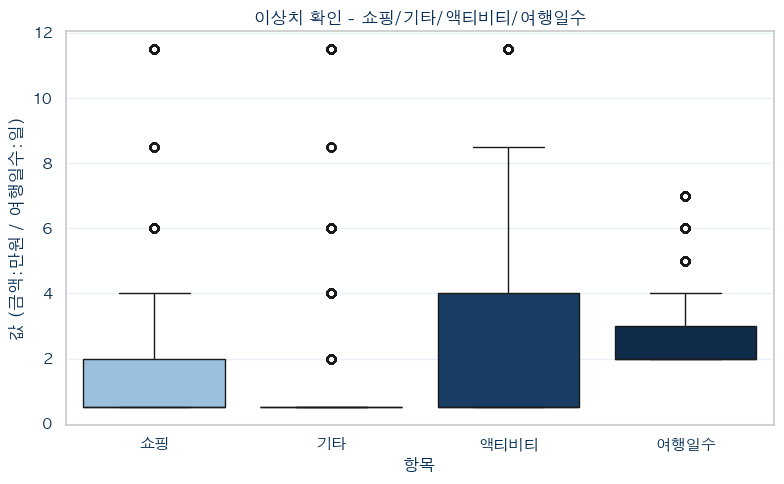

In [20]:

set_plot_style()
# (중복 컬럼 제거·리네임이 이미 되어 있다는 전제. 안 되어 있으면 앞 단계 코드 먼저 실행)

item_mid_map = {'1만원 미만':0.5, '1~3만원 미만':2, '3~5만원 미만':4, '5~7만원 미만':6, '7~10만원 미만':8.5, '10만원 이상':11.5}
pd_map = {'1박 2일':2, '2박 3일':3, '3박 4일':4, '4박 5일':5, '5박 6일':6, '6박 7일 이상':7}

cols = {
    'TOUR_SHOPNG_CT_VALUE': ('쇼핑', item_mid_map),
    'TOUR_ETC_CT_VALUE': ('기타', item_mid_map),
    'TOUR_ACTVTY_CT_VALUE': ('액티비티', item_mid_map),
    'TOUR_PD_VALUE': ('여행일수', pd_map),
}

long_rows = []

for col, (label, mapping) in cols.items():
    mapped_series = df[col].map(mapping)
    long_rows.append(pd.DataFrame({'항목': label, '값': mapped_series}).dropna())

full_long = pd.concat(long_rows, ignore_index=True)

order = ['쇼핑', '기타', '액티비티', '여행일수']

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=full_long, x='항목', y='값', hue='항목', order=order, palette=get_palette(4), legend=False, ax=ax)
ax.set_title('이상치 확인 - 쇼핑/기타/액티비티/여행일수')
ax.set_ylabel('값 (금액:만원 / 여행일수:일)')

plt.tight_layout()
plt.show()

#### `TOUR_SHOPNG_CT_VALUE` / `TOUR_ETC_CT_VALUE` / `TOUR_ACTVTY_CT_VALUE`  (쇼핑, 기타, 액티비티 비용): 15.08%, 16.14%, 6.42%

1. 상한 절단
    - 응답자가 실제로 선택한 유효한 설문 응답을 인위적으로 잘라내는 것, 표본 왜곡
2. 이상치 행 삭제
    - 삭제 후 재계산해도 남은 데이터에서 또 새로운 값이 이상치로 잡혀 반복됨
4. [v] 처리하지 않음
    - 응답자 대부분이 해당 항목을 거의 안 쓰는 구조라 IQR이 극단적으로 좁아지며 생김

In [21]:
# 이상치 행 삭제 시도
item_mid_map = {'1만원 미만':0.5,'1~3만원 미만':2,'3~5만원 미만':4,'5~7만원 미만':6,'7~10만원 미만':8.5,'10만원 이상':11.5}
mapped_values = df['TOUR_ACTVTY_CT_VALUE'].map(item_mid_map).dropna()

q1, q3 = mapped_values.quantile(0.25), mapped_values.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
print(f'[1차] 정상범위[{lower}, {upper}], 이상치 {((mapped_values<lower)|(mapped_values>upper)).sum()}건')

filtered_values = mapped_values[~((mapped_values < lower) | (mapped_values > upper))]  # 이상치 제거
q1b, q3b = filtered_values.quantile(0.25), filtered_values.quantile(0.75)
iqrb = q3b - q1b
lowerb, upperb = q1b - 1.5*iqrb, q3b + 1.5*iqrb
print(f'[2차-재계산] 정상범위[{lowerb}, {upperb}], 새 이상치 {((filtered_values<lowerb)|(filtered_values>upperb)).sum()}건')

[1차] 정상범위[-4.75, 9.25], 이상치 751건
[2차-재계산] 정상범위[-1.75, 4.25], 새 이상치 1409건


#### `TOUR_PD_VALUE` (여행기간): 9.35%
1. 상한 절단(4박5일 이상을 4로)
    - 응답자가 실제로 선택한 유효한 응답이라 장기 여행자 표본이 왜곡
2. [v] 처리하지 않음
    - 설문 자체가 1~7의 좁은 정수 구간으로 응답을 제한하고 있어 IQR이 짧은 여행에 맞춰짐

In [22]:
# 정상 범위 및 이상치 값 확인
pd_map = {'1박 2일':2,'2박 3일':3,'3박 4일':4,'4박 5일':5,'5박 6일':6,'6박 7일 이상':7}
mapped_values = df['TOUR_PD_VALUE'].map(pd_map).dropna()
q1, q3 = mapped_values.quantile(0.25), mapped_values.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = mapped_values[(mapped_values < lower) | (mapped_values > upper)]
print(f'정상범위[{lower}, {upper}]')
print(f'이상치로 잡힌 값: {sorted([float(value) for value in outliers.unique()])}')

정상범위[0.5, 4.5]
이상치로 잡힌 값: [5.0, 6.0, 7.0]


#### 이상치 처리 기준
- 이상치 처리X
    - 이상치 없음(수치/순서형): `TOUR_TOT_CT_VALUE`, `TOUR_LDGMNT_CT_VALUE`, `TOUR_FOOD_CT_VALUE`, `TOUR_TRNSPORT_CT_VALUE`, `TOUR_COM_NMPR_NM`, `AGRDE_FLAG_NM`
    - 희귀 카테고리 없음(명목형): `TOUR_CTPRVN_NM`, `COM_ONE_TY`, `TOUR_PURPS_NM`, `SEXDSTN_FLAG_CD`, `MRRG_AT_NM`, `CHLDRN_TY_NM`, `OCCP_NM`
- 이상치 처리O
    - `TOUR_SHOPNG_CT_VALUE` (15.80%): 처리하지 않음(원본 유지)
    - `TOUR_ETC_CT_VALUE` (16.14%): 처리하지 않음(원본 유지)
    - `TOUR_ACTVTY_CT_VALUE` (6.42%): 처리하지 않음(원본 유지)
    - `TOUR_PD_VALUE` (9.35%): 처리하지 않음(원본 유지)

### 손상 레코드

##### 손상 레코드 확인

1. 시간 순서 제약
    - 여행일이 조사일보다 늦을 수 없음
    - 확인: 여행-조사 시점 모순 (TOUR_BEGIN_DE > EXAMIN_BEGIN_DE인 경우)
2. 동일 개체 고정 속성
    - 같은 응답자(RESPOND_ID)라면 성별, 연령대 같은 값이 바뀌지 않아야 함
    - 확인: 동일응답자-성별 충돌 (같은 RESPOND_ID인데 성별이 다른 경우)
    - 확인: 동일응답자-연령대 2단계+ 충돌 (같은 RESPOND_ID인데 연령대가 2단계 이상 차이나는 경우)
3. 물리적 자원 충돌
    - 한 사람이 같은 기간에 두 개의 여행을 동시에 다녀올 수 없음
    - 확인: 여행기간 물리적 겹침 (같은 응답자의 서로 다른 두 여행 기간이 겹치는 경우)
4. 중복 키
    - 같은 응답자 + 같은 여행 시작일 조합인데 조사회차마다 응답이 달라지면 안됨
    - 확인: 동일 여행 중복 응답 (동일 응답자+동일 여행시작일이 여러 조사회차에 걸쳐 응답된 경우)
    - 확인: 동일여행-지역 충돌 (위 중복 응답 중 여행 지역까지 다르게 기록된 경우)

In [23]:
# 여행일이 조사일보다 늦은 경우 (시간 순서 위반)
count_time_order_violation = (df['TOUR_BEGIN_DE'] > df['EXAMIN_BEGIN_DE']).sum()

# 동일 응답자+여행일이 여러 조사회차에 중복 응답된 경우
trip_group_sizes = df.groupby(['RESPOND_ID', 'TOUR_BEGIN_DE']).size()
duplicate_trip_groups = trip_group_sizes[trip_group_sizes > 1]
count_duplicate_trip_response = duplicate_trip_groups.sum() - len(duplicate_trip_groups)

# 동일 여행인데 지역 응답이 회차마다 다른 경우
region_per_trip = df.groupby(['RESPOND_ID', 'TOUR_BEGIN_DE'])['TOUR_CTPRVN_NM'].nunique()
count_region_conflict = (region_per_trip > 1).sum()

# 동일 응답자인데 성별이 응답마다 다른 경우
sex_per_respondent = df.groupby('RESPOND_ID')['SEXDSTN_FLAG_CD'].nunique()
count_sex_conflict = (sex_per_respondent > 1).sum()

# 동일 응답자인데 연령대가 2단계 이상 차이나는 경우
age_order_map = {'20대': 1, '30대': 2, '40대': 3, '50대': 4, '60대 이상': 5}
df['AGE_NUM'] = df['AGRDE_FLAG_NM'].map(age_order_map)
age_range_per_respondent = df.groupby('RESPOND_ID')['AGE_NUM'].agg(['min', 'max'])
count_age_conflict = ((age_range_per_respondent['max'] - age_range_per_respondent['min']) >= 2).sum()

# 동일 응답자의 서로 다른 두 여행 기간이 물리적으로 겹치는 경우
trip_duration_map = {'1박 2일': 2, '2박 3일': 3, '3박 4일': 4, '4박 5일': 5, '5박 6일': 6, '6박 7일 이상': 7}
df['TRIP_DAYS'] = df['TOUR_PD_VALUE'].map(trip_duration_map)
df['TOUR_BEGIN_DATE'] = pd.to_datetime(df['TOUR_BEGIN_DE'], format='%Y%m%d', errors='coerce')
df['TOUR_END_DATE'] = df['TOUR_BEGIN_DATE'] + pd.to_timedelta(df['TRIP_DAYS'].fillna(1) - 1, unit='D')

count_trip_overlap = 0
for respondent_id, trips in df[df['TOUR_BEGIN_DATE'].notna()].groupby('RESPOND_ID'):
    if len(trips) < 2:
        continue
    trips = trips.sort_values('TOUR_BEGIN_DATE')
    begin_dates, end_dates = trips['TOUR_BEGIN_DATE'].values, trips['TOUR_END_DATE'].values
    for i in range(len(trips) - 1):
        if end_dates[i] > begin_dates[i + 1]:
            count_trip_overlap += 1

# 손상 레코드 유형별 요약
corrupted_summary = pd.DataFrame([
    {'유형': '여행-조사 시점 모순', '건수': count_time_order_violation},
    {'유형': '동일 여행 중복 응답(잉여분)', '건수': count_duplicate_trip_response},
    {'유형': '동일여행-지역 충돌', '건수': count_region_conflict},
    {'유형': '동일응답자-성별 충돌', '건수': count_sex_conflict},
    {'유형': '동일응답자-연령대 2단계+ 충돌', '건수': count_age_conflict},
    {'유형': '여행기간 물리적 겹침', '건수': count_trip_overlap},
]).set_index('유형')

corrupted_summary['비율(%)'] = (corrupted_summary['건수'] / len(df) * 100).round(2)
corrupted_summary = corrupted_summary.sort_values('비율(%)', ascending=False)

print(corrupted_summary)
print(df.shape)

                    건수  비율(%)
유형                           
여행기간 물리적 겹침        109   0.76
동일 여행 중복 응답(잉여분)    87   0.61
여행-조사 시점 모순         47   0.33
동일응답자-성별 충돌         34   0.24
동일여행-지역 충돌           5   0.03
동일응답자-연령대 2단계+ 충돌    5   0.03
(14342, 31)


#### 손상 레코드 처리

##### 여행-조사 시점 모순 (`TOUR_BEGIN_DE` > `EXAMIN_BEGIN_DE`): 47건 (0.33%)

1. 날짜 보정 (여행일을 조사일 이전으로 임의 수정)
    - 어느 날짜가 오기입인지 알 수 없어 임의 보정이 새로운 오류를 만들 수 있음
2. 두 날짜를 서로 맞바꿈
    - 여행일과 조사일은 같은 사건의 시작/종료가 아니라 서로 다른 두 사건의 날짜이므로, 맞바꿔도 모순이 자리만 바꾼 것
3. [v] 행 삭제
    - 전체의 0.33%로 비중이 작고, 조사 설계상 존재할 수 없는 조합을 남겨두는 것보다 제거가 안전

##### 동일 여행 중복 응답 (동일 `RESPOND_ID`+`TOUR_BEGIN_DE` 여러 조사 회차): 잉여 87건 (0.61%)

1. 평균/합산 처리
    - 범주형 항목은 평균을 낼 수 없고, 지출액도 구간값을 평균 내면 원래 구간 정의를 벗어남
2. 임의로 한 건 선택(첫 번째 등)
    - 어떤 기준으로 선택했는지 설명할 수 없어 재현성이 없음
3. [v] 최신 조사회차(EXAMIN_BEGIN_DE 최댓값) 유지
    - 반복 조사에서 다시 물었다면 응답자가 기억을 정리했거나 정정했을 가능성이 있는 최근 응답을 채택하는 게 유일하게 근거를 댈 수 있는 기준
    - (부수효과) "동일여행-지역 충돌" 5건도 같은 그룹의 부분집합이라 최신 회차만 남기면 자동으로 함께 해결됨

##### 동일응답자 - 성별 충돌 (같은`RESPOND_ID`인데 `SEXDSTN_FLAG_CD`가 다름): 34명 (0.24%)

1. 다수결(최빈값)로 응답자 전체 통일
    - 대부분 2건 뿐이라 다수결 자체가 안 되는 경우가 많고 어느 게 오류인지 판단 근거 없음
2. 해당 응답자 행 전체 삭제
    - 보조 변수 하나 때문에 핵심 지출, 지역 데이터까지 통째로 버리는 건 손실 대비 실익이 적음
3. [v] 처리하지 않음
    - 보조 변수라 핵심 분석에 영향이 없고, "응답자 개인의 고정 속성"이 아니라 "그 여행 건에 대한 응답값"으로 해석하면 모순이 아님

##### 동일응답자 - 연령대 충돌 (같은 `RESPOND_ID`인데 `AGRDE_FLAG_NM`이 2단계 이상 차이): 5명/관련 10건 (0.03%)

1. 최빈값/최신값으로 통일
    - `AGRDE_FLAG_NM`은 연령대 쏠림을 판별하는 핵심 변수
    - 값을 임의로 골라 쓰면 판단 자체가 왜곡될 위험이 있음
2. [v] 해당 응답자 행 전체 삭제
    - 10건(0.07%)으로 손실이 미미하고, 핵심 변수라 애매한 값을 남겨두는 것보다 제거가 안전

##### 여행기간 물리적 겹침 (같은 응답자의 두 여행 기간이 겹침): 109건 (0.76%)

1. 나중에 시작한 여행 삭제
    - 응답자가 과거 여행을 기억에 의존해 응답하는 조사 특성상 시작일 자체가 부정확할 수 있음
    - 겹침 판정에 쓴 임시 종료일(_TMP_TRIP_DAYS, "6박7일 이상"→7일 근사)의 오차에서 비롯됐을 가능성도 있어 실제 오류로 단정하기 애매함
2. [v] 처리하지 않음(원본 유지)
    - 핵심 분석 단위는 "여행 건" 각각
    - 두 여행이 살짝 겹친다고 해서 각 건의 지역, 지출 데이터 자체가 틀린 것은 아님

### 파생 변수

| 예상 컬럼명 | 의미하는 바 | 만들 예정 로직 |
|---|---|---|
| `TRIP_DAYS` | 여행일수를 숫자로 비교/평균 낼 수 있게 함. <br />"1박 2일" 문자열로는 평균 여행일수·기간별 지출 비교가 불가능 | TOUR_PD_VALUE를 "1박 2일"→2, "2박 3일"→3, ..., "6박 7일 이상"→7로 매핑.<br />'모름'은 결측으로 남김 |
| `TOTAL_EXP_MID_MANWON` | 지역별 평균 지출을 계산할 수 있게 함. <br />"많이 오지만 지출은 낮은 지역"을 가려내려면 지역별 평균이 필요한데 문자열 구간으로는 평균 불가 | TOUR_TOT_CT_VALUE를 "10만원 미만"→5, "10~20만원 미만"→15, "20~30만원 미만"→25, "30~40만원 미만"→35, "40만원 이상"→45(구간중앙값, 만원)로 매핑 |
| `TRAVEL_STYLE_GROUP` | 챗봇이 사용자의 "홀로/단체" 여행 스타일 입력과 매칭할 수 있게 함. <br />동행인원 원본이 카테고리가 너무 세분화돼 조건 필터링에 그대로 쓰기 어려움 | TOUR_COM_NMPR_NM을 "혼자서"→1인(홀로여행), "2명/3명"→2~3인(소규모 동반), "4명/5명 이상"→4인 이상(단체 동반)로 매핑 |
| `TRAVEL_MONTH` | 시기별 방문 집중도를 월 단위로 집계할 수 있게 함. <br />날짜 전체(YYYYMMDD)로는 "몇 월에 몰리는지" 바로 볼 수 없음 | TOUR_BEGIN_DE(YYYYMMDD)에서 월(1~12)만 추출 |
| `IS_PEAK_SEASON` | 챗봇이 "이 시기는 붐빈다/한산하다"를 True/False로 바로 판단할 수 있게 함. <br />TRAVEL_MONTH만으로도 계산 가능하지만 매번 몇 월인지 나열하지 않아도 되게 함 | TRAVEL_MONTH가 [5,6,7,8]에 속하는지로 True/False 생성. <br />(통상적 "7·8·12·1·2월=성수기" 가정은 실측 비중상 근거 없어(12월 최저) 실제 상위 4개월로 재정의) |

## [3] 전처리 적용 및 cleaned 데이터셋 생성

### 데이터 불러오기

In [24]:
df = pd.read_csv('data/processed/travel_timing_expenditure_2025.csv')
print(f'데이터 불러오기: {df.shape}')

데이터 불러오기: (14342, 38)


### 중복 컬럼 제거


In [25]:
# '_x' 접미사 컬럼 중 대응하는 '_y'가 있고, 값까지 완전히 일치하는 쌍만 병합
x_cols = [col for col in df.columns if col.endswith('_x')]
same_pair_list = [col[:-2] for col in x_cols if col[:-2] + '_y' in df.columns]

full_duplicate = [
    name for name in same_pair_list
    if (df[name + '_x'].fillna('__NA__') == df[name + '_y'].fillna('__NA__')).mean() == 1.0
]

df = df.drop(columns=[name + '_y' for name in full_duplicate]).rename(
    columns={name + '_x': name for name in full_duplicate}
)
print(f'중복 컬럼 제거: {df.shape}')

중복 컬럼 제거: (14342, 27)


### 결측치 처리


In [26]:
# 결측 판단 기준: NaN 또는 '모름' 문자열 응답
def is_missing(series):
    return series.isna() | series.astype(str).str.contains('모름', na=False)

# TOUR_TOT_CT_VALUE: 대체할 원천 데이터 없어 결측행 삭제
df = df[~is_missing(df['TOUR_TOT_CT_VALUE'])]

# TOUR_COM_NMPR_NM: 여행스타일 판별 핵심 변수, 결측행 삭제
df = df[~is_missing(df['TOUR_COM_NMPR_NM'])]

# COM_ONE_TY: 보조 변수, 결측을 '미상' 카테고리로 유지
df.loc[is_missing(df['COM_ONE_TY']), 'COM_ONE_TY'] = '미상'

# TOUR_PD_VALUE: 행은 유지, 파생변수(TRIP_DAYS) 생성 시점에만 결측 처리
print(f'결측치 처리: {df.shape}')

결측치 처리: (11353, 27)


### 이상치 처리


In [27]:
# [2]에서 검토 결과 전 항목 원본 유지로 결정

### 손상 레코드 처리


In [ ]:
# 여행-조사 시점 모순: 여행일이 조사일보다 늦을 수 없음 -> 삭제
df = df[df['TOUR_BEGIN_DE'] <= df['EXAMIN_BEGIN_DE']]

# 동일 응답자+동일 여행시작일이 여러 조사회차에 응답된 경우 -> 최신 회차만 유지
# (부수효과: 동일 여행 내 지역 응답 충돌도 함께 해결됨)
latest_idx = df.groupby(['RESPOND_ID', 'TOUR_BEGIN_DE'])['EXAMIN_BEGIN_DE'].idxmax()
df = df.loc[latest_idx]

# 동일 응답자인데 연령대가 2단계 이상 차이나는 경우 -> 해당 응답자 행 전체 삭제
age_order_map = {'20대': 1, '30대': 2, '40대': 3, '50대': 4, '60대 이상': 5}
age_num = df['AGRDE_FLAG_NM'].map(age_order_map)
age_range_per_respondent = age_num.groupby(df['RESPOND_ID']).agg(['min', 'max'])
conflicted_respondents = age_range_per_respondent[
    (age_range_per_respondent['max'] - age_range_per_respondent['min']) >= 2
].index
df = df[~df['RESPOND_ID'].isin(conflicted_respondents)]

# 성별 충돌, 여행기간 물리적 겹침: 보조 변수/개별 여행 건 데이터 훼손 없다고 판단해 처리하지 않음
print(f'손상 레코드 처리: {df.shape}')

손상 레코드 처리: (11242, 27)


### 파생 변수 생성


In [29]:
# TRIP_DAYS: 여행일수를 숫자로 변환 (매핑 밖 값은 결측으로 남음)
df['TRIP_DAYS'] = df['TOUR_PD_VALUE'].map(numeric_convertible['TOUR_PD_VALUE'])

# TOTAL_EXP_MID_MANWON: 총비용 구간을 구간중앙값(만원)으로 변환
df['TOTAL_EXP_MID_MANWON'] = df['TOUR_TOT_CT_VALUE'].map(numeric_convertible['TOUR_TOT_CT_VALUE'])

# TRAVEL_STYLE_GROUP: 동행인원을 홀로/소규모/단체 3단계로 묶음
companion_count = df['TOUR_COM_NMPR_NM'].map(numeric_convertible['TOUR_COM_NMPR_NM'])
df['TRAVEL_STYLE_GROUP'] = pd.cut(
    companion_count, bins=[0, 1, 3, companion_count.max()],
    labels=['홀로여행', '소규모 동반', '단체 동반']
)

# TRAVEL_MONTH: 여행시작일(YYYYMMDD)에서 월만 추출
df['TRAVEL_MONTH'] = pd.to_datetime(df['TOUR_BEGIN_DE'], format='%Y%m%d', errors='coerce').dt.month

# IS_PEAK_SEASON: 실측 응답 비중 상위 4개월을 성수기로 동적 산출 (하드코딩 대신 데이터 기반)
peak_months = df['TRAVEL_MONTH'].value_counts().head(4).index
df['IS_PEAK_SEASON'] = df['TRAVEL_MONTH'].isin(peak_months)

print(df[['TRIP_DAYS', 'TOTAL_EXP_MID_MANWON', 'TRAVEL_STYLE_GROUP', 'TRAVEL_MONTH', 'IS_PEAK_SEASON']].head())
print(f'파생 변수 생성: {df.shape}')

       TRIP_DAYS  TOTAL_EXP_MID_MANWON TRAVEL_STYLE_GROUP  TRAVEL_MONTH  \
6471         3.0                    45               홀로여행            10   
3595         2.0                    25             소규모 동반             9   
6464         2.0                    45               홀로여행            10   
12023        2.0                     5             소규모 동반             1   
10266        3.0                    35             소규모 동반             8   

       IS_PEAK_SEASON  
6471            False  
3595            False  
6464            False  
12023           False  
10266            True  
파생 변수 생성: (11242, 32)


### cleaned.csv 생성

In [ ]:
# 컬럼 정의표에서 미사용으로 판단한 컬럼만 제외, 나머지 원본 컬럼 + 파생변수는 모두 보존
unused_columns = [
    'TOUR_SIGNGU_NM', 'HSHLD_INCOME_DGREE_NM', 
    'COM_TWO_TY', 'COM_THREE_TY', 'COM_FOUR_TY', 'COM_FIVE_TY', 'COM_SIX_TY',
]
derived_columns = ['TRIP_DAYS', 'TOTAL_EXP_MID_MANWON', 'TRAVEL_STYLE_GROUP', 'TRAVEL_MONTH', 'IS_PEAK_SEASON']

cleaned_df = df.drop(columns=unused_columns).reset_index(drop=True)
cleaned_df.to_csv('data/cleaned/ryukyung_travel_timing_expenditure_2025_cleaned.csv', index=False)
print(f'cleaned.csv 생성: {cleaned_df.shape}')

cleaned.csv 생성: (11242, 25)
